In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
colors = ["#17BECF", "#E377C2", "#BCBD22"]
cmap = ListedColormap(colors)

import pickle

import pandas as pd

from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from scipy.spatial.distance import cdist
from sklearn.metrics import rand_score

from openTSNE import TSNE
from phate import PHATE
from sklearn.manifold import Isomap
from sklearn.decomposition import PCA
from umap import UMAP

import sys
sys.path.append('../code')
from align import *
from eval import *
from util import *

import time

# Load data

In [3]:
df = pd.read_csv('../data/shapes_3d.csv')
data = df.to_numpy()
X = data[:,0:3]
labels = data[:,-1]
n = len(data)
n

1000

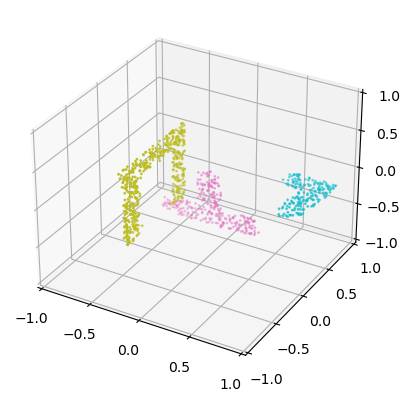

In [11]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(data[:,0], data[:,1], data[:,2], c=labels, cmap = cmap, s = 1)
ax.set_xlim(-1,1)
ax.set_ylim(-1,1)
ax.set_zlim(-1,1)
ticks = np.arange(-1, 1.5, 0.5)
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_zticks(ticks)

plt.savefig('../figures/shapes_I/original_data.png', format='png', dpi=300, bbox_inches='tight')

# Cluster data

In [1]:

db = DBSCAN(eps=0.1, min_samples=10)
clusters = db.fit_predict(data)


In [21]:
rand_score(clusters, labels)

1.0

# Embed each cluster

In [2]:

pca  = PCA(n_components = 2)
embeddings = np.zeros((n,2))
for i in np.unique(clusters):
    embeddings[clusters == i] = pca.fit_transform(X[clusters == i,:])

# Align 

In [3]:

distances = {}
n_clusters = len(np.unique(clusters))
for i in range(n_clusters):
    cluster_i = X[clusters == i,]
    for j in range(i+1, n_clusters):
        cluster_j = X[clusters == j,:]
        distances[i,j] = cdist(cluster_i, cluster_j)


In [4]:

out = Embedding(embeddings, clusters, distances, alpha =1)
ce_emb = out.align_embedding(m = 50)


In [5]:

out = Embedding(embeddings, clusters, distances, alpha =1.25)
ce_emb_alpha = out.align_embedding(m = 50)


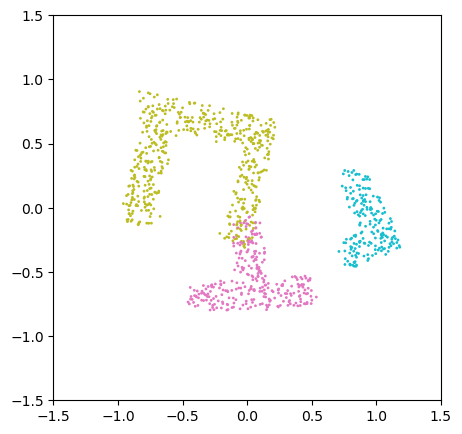

In [14]:
plt.figure(figsize = [5,5])
plt.scatter(ce_emb[:,0], ce_emb[:,1], c = labels, cmap = cmap, s = 1)
plt.xlim(-1.5,1.5)
plt.ylim(-1.5,1.5)
plt.xticks(np.arange(-1.5, 1.6, .5))
plt.yticks(np.arange(-1.5, 1.6, .5))
plt.savefig('../figures/shapes_I/ce.png', format='png', dpi=300, bbox_inches='tight')

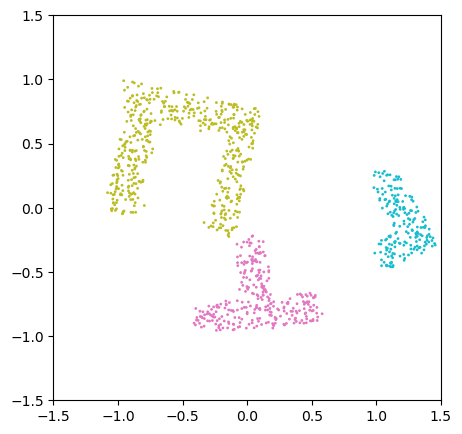

In [15]:
plt.figure(figsize = [5,5])
plt.scatter(ce_emb_alpha[:,0], ce_emb_alpha[:,1], c = labels, cmap = cmap, s = 1)
plt.xlim(-1.5,1.5)
plt.ylim(-1.5,1.5)
plt.xticks(np.arange(-1.5, 1.6, .5))
plt.yticks(np.arange(-1.5, 1.6, .5))
plt.savefig('../figures/shapes_I/ce_125.png', format='png', dpi=300, bbox_inches='tight')

In [6]:

tsne30 = TSNE(perplexity = 30).fit(X)
tsne30 = np.array(tsne30)


In [ ]:
tsne260 = TSNE(perplexity = 260).fit(X)
tsne260 = np.array(tsne30)

In [7]:

pca = PCA(n_components = 2).fit_transform(X)


In [8]:

isomap = Isomap(n_neighbors=200).fit_transform(X)


In [9]:

umap = UMAP().fit_transform(X)


In [10]:

phate = PHATE().fit_transform(X)


In [4]:
#due to environment issues, this was computed separatley and then loaded 
trimap =  np.load("../results/shapes_I/trimap.npy", allow_pickle=False)

In [7]:
tsne30_, _  = procrustes(ce_emb, tsne30)
tsne260_, _  = procrustes(ce_emb, tsne260)
pca_, _  = procrustes(ce_emb, pca)
isomap_, _  = procrustes(ce_emb, isomap)
umap_, _  = procrustes(ce_emb, umap)
phate_, _  = procrustes(ce_emb, phate)
trimap_, _  = procrustes(ce_emb, trimap)

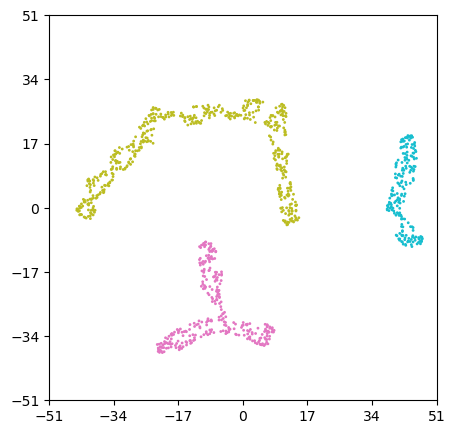

In [17]:
plt.figure(figsize = [5,5])
plt.scatter(tsne30_[:,0], tsne30_[:,1], c = labels, cmap = cmap, s = 1)
plt.xlim(-51,51)
plt.ylim(-51,51)
plt.xticks(np.linspace(-51,51,7))
plt.yticks(np.linspace(-51,51,7))
plt.savefig('../figures/shapes_I/tsne_30.png', format='png', dpi=300, bbox_inches='tight')

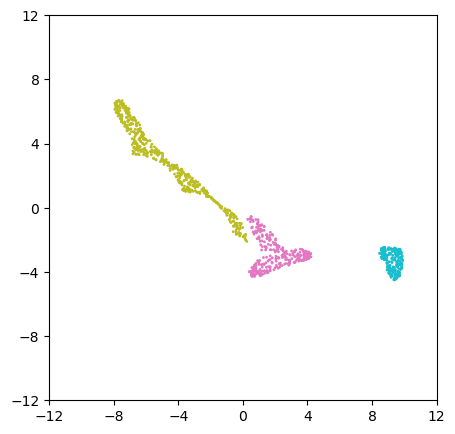

In [18]:
plt.figure(figsize = [5,5])
plt.scatter(tsne260_[:,0], tsne260_[:,1], c = labels, cmap = cmap, s = 1)

plt.xlim(-12,12)
plt.ylim(-12,12)
plt.xticks(np.linspace(-12,12,7))
plt.yticks(np.linspace(-12,12,7))

plt.savefig('../figures/shapes_I/tsne_260.png', format='png', dpi=300, bbox_inches='tight')

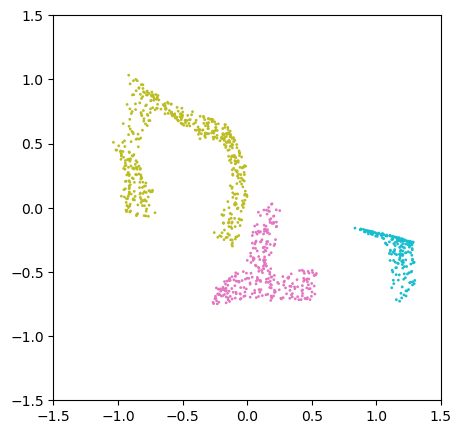

In [19]:
plt.figure(figsize = [5,5])
plt.scatter(isomap_[:,0], isomap_[:,1], c = labels, cmap = cmap, s = 1)

plt.xlim(-1.5,1.5)
plt.ylim(-1.5,1.5)
plt.xticks(np.arange(-1.5, 1.6, .5))
plt.yticks(np.arange(-1.5, 1.6, .5))
plt.savefig('../figures/shapes_I/isomap.png', format='png', dpi=300, bbox_inches='tight')

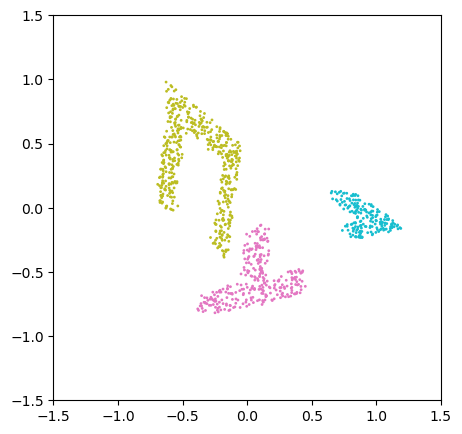

In [20]:
plt.figure(figsize = [5,5])
plt.scatter(pca_[:,0], pca_[:,1], c = labels, cmap = cmap, s = 1)
plt.xlim(-1.5,1.5)
plt.ylim(-1.5,1.5)
plt.xticks(np.arange(-1.5, 1.6, .5))
plt.yticks(np.arange(-1.5, 1.6, .5))


plt.savefig('../figures/shapes_I/pca.png', format='png', dpi=300, bbox_inches='tight')

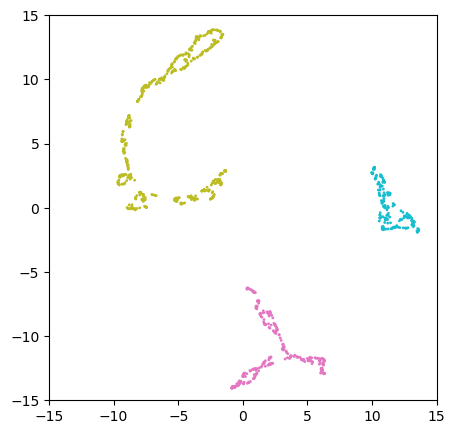

In [21]:
plt.figure(figsize = [5,5])
plt.scatter(umap_[:,0], umap_[:,1], c = labels, cmap = cmap, s = 1)

plt.xlim(-15,15)
plt.ylim(-15,15)
plt.xticks(np.arange(-15, 16, 5))
plt.yticks(np.arange(-15, 16, 5))
plt.savefig('../figures/shapes_I/umap.png', format='png', dpi=300, bbox_inches='tight')

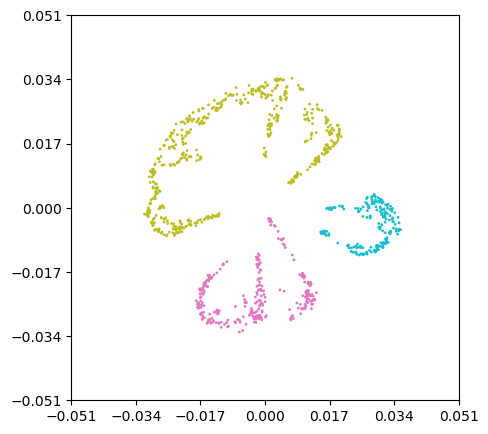

In [22]:
plt.figure(figsize = [5,5])
plt.scatter(phate_[:,0], phate_[:,1], c = labels, cmap = cmap, s = 1)

plt.xlim(-.051,.051)
plt.ylim(-.051,.051)
plt.xticks(np.linspace(-.051,.051,7))
plt.yticks(np.linspace(-.051,.051,7))


plt.savefig('../figures/shapes_I/phate.png', format='png', dpi=300, bbox_inches='tight')

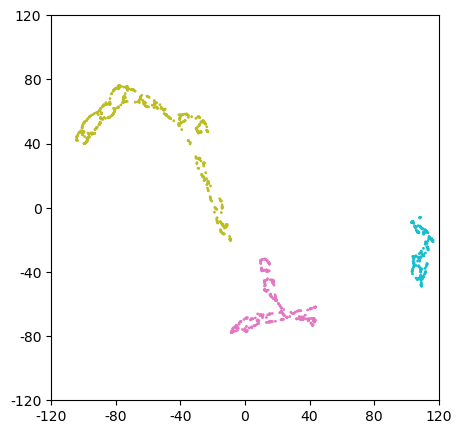

In [12]:
plt.figure(figsize = [5,5])
plt.scatter(trimap_[:,0], trimap_[:,1], c = labels, cmap = cmap, s = 1)

plt.xlim(-117,123)
plt.ylim(-120,120)
plt.xticks(np.linspace(-117,123,7),np.linspace(-120,120,7).astype(int))
plt.yticks(np.linspace(-120,120,7),np.linspace(-120,120,7).astype(int))


plt.savefig('../figures/shapes_I/trimap.png', format='png', dpi=300, bbox_inches='tight')

In [23]:
#gather embeddings and save them

all_embs = [ce_emb, ce_emb_alpha, tsne30, tsne260, pca, isomap, umap, phate]
results = [all_embs, labels, clusters]

with open('../results/shapes_I/embeddings.pkl', 'wb') as file:  
    pickle.dump(results, file)

# Evaluation 

In [5]:
#load embeddings
with open('../results/shapes_I/embeddings.pkl', 'rb') as file:
    results = pickle.load(file)
all_embs, labels, clusters = results

In [6]:
ce_emb, ce_emb_alpha, tsne30, tsne260, pca, isomap, umap, phate = all_embs

In [13]:
labels = labels -1 #zero index

In [8]:
orig_distances = squareform(pdist(X))

for emb in all_embs:
    emb_distances =  squareform(pdist(emb))
    spearman_scores = spearman(orig_distances, emb_distances, labels)
    stress_scores = normalized_stress(orig_distances, emb_distances, labels)
    class_score = class_preservation(orig_distances, emb_distances, labels)
    scaled_stress_scores =  scale_normalized_stress(orig_distances, emb_distances, labels)
    recall_score = knn_recall(X, emb, [30])
    
    formatted = " & ".join(
    [
        f"${spearman_scores[0]:.2f}$",
        f"${stress_scores[0]:.2f}$",
        f"${scaled_stress_scores[0]:.2f}$",
        f"${recall_score[0]:.2f}$",
        *[f"${x:.2f}$" for x in spearman_scores[1:]],
        *[f"${x:.2f}$" for x in stress_scores[1:]],
        *[f"${x:.2f}$" for x in scaled_stress_scores[1:]],
        f"${class_score:.2f}$"
    ]
)


    print(formatted)
    print()

$1.00$ & $0.00$ & $0.00$ & $0.96$ & $0.96$ & $0.98$ & $0.09$ & $0.09$ & $0.09$ & $0.09$ & $1.00$

$1.00$ & $0.00$ & $0.00$ & $1.00$ & $0.96$ & $0.98$ & $0.25$ & $0.24$ & $0.07$ & $0.10$ & $1.00$

$0.93$ & $41.11$ & $0.20$ & $0.87$ & $0.71$ & $0.84$ & $46.17$ & $43.50$ & $0.19$ & $0.23$ & $-0.33$

$0.95$ & $4.02$ & $0.18$ & $0.88$ & $0.70$ & $0.93$ & $7.65$ & $7.99$ & $0.18$ & $0.26$ & $1.00$

$0.92$ & $0.28$ & $0.19$ & $0.84$ & $0.98$ & $0.98$ & $0.06$ & $0.12$ & $0.05$ & $0.11$ & $1.00$

$0.94$ & $0.19$ & $0.16$ & $0.83$ & $0.90$ & $0.98$ & $0.15$ & $0.21$ & $0.08$ & $0.15$ & $1.00$

$0.93$ & $9.03$ & $0.17$ & $0.81$ & $0.60$ & $0.88$ & $13.75$ & $13.70$ & $0.16$ & $0.23$ & $0.33$

$0.73$ & $0.96$ & $0.35$ & $0.65$ & $0.22$ & $0.68$ & $0.97$ & $0.97$ & $0.31$ & $0.32$ & $1.00$



In [16]:
orig_distances = squareform(pdist(X))

for emb in [trimap]:
    emb_distances =  squareform(pdist(emb))
    spearman_scores = spearman(orig_distances, emb_distances, labels)
    stress_scores = normalized_stress(orig_distances, emb_distances, labels)
    class_score = class_preservation(orig_distances, emb_distances, labels)
    scaled_stress_scores =  scale_normalized_stress(orig_distances, emb_distances, labels)
    recall_score = knn_recall(X, emb, [30])
    
    formatted = " & ".join(
    [
        f"${spearman_scores[0]:.2f}$",
        f"${stress_scores[0]:.2f}$",
        f"${scaled_stress_scores[0]:.2f}$",
        f"${recall_score[0]:.2f}$",
        *[f"${x:.2f}$" for x in spearman_scores[1:]],
        *[f"${x:.2f}$" for x in stress_scores[1:]],
        *[f"${x:.2f}$" for x in scaled_stress_scores[1:]],
        f"${class_score:.2f}$"
    ]
)


    print(formatted)
    print()

$0.93$ & $66.38$ & $0.21$ & $0.79$ & $0.82$ & $0.95$ & $112.28$ & $114.00$ & $0.11$ & $0.19$ & $1.00$



In [43]:

recall_results = []

for emb in all_embs:
    recall_score = knn_recall(X, emb, np.arange(5,200,5))
    recall_results += [recall_score]

In [10]:
colors = ['#3182bd', '#aec7e8', '#ff7f0e','#ffbb78', '#d62728', '#31a354',  '#8c564b','#9467bd']


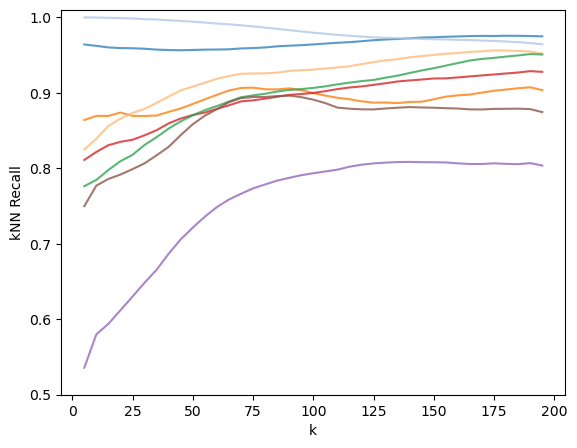

In [12]:

plt.figure(figsize = [6.5,5])
method_labels  = [r'C+E ($\alpha = 1$)', r'C+E ($\alpha = 1.25$)', 't-SNE (u = 30)', 't-SNE (u = 260)',
          'PCA', 'Isomap', 'UMAP', 'PHATE']
for i,r in enumerate(recall_results):
    plt.plot(np.arange(5,200,5), r, label = method_labels[i], color = colors[i], alpha = .8)
# plt.legend()
plt.xlabel('k')
plt.ylabel('kNN Recall')
plt.ylim(0.5,1.01)
# 
plt.savefig('../figures/shapes_I/knn.png', format='png', dpi=300, bbox_inches='tight')

In [89]:
with open('../results/shapes_I/recall.pkl', 'wb') as file:  
    pickle.dump(recall_results, file)

In [3]:
with open('../results/shapes_I/recall.pkl', 'rb') as file:  
    recall_results = pickle.load(file)